In [ ]:
#Importing Libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
import re
import nltk
import csv

nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shivani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Load and Fix the Dataset

In [7]:
# ✅ Load your CSV (update your file path)
file_path = r"C:\Users\shivani\OneDrive\Desktop\23p65a6717\twitter_training.csv"

# Read safely even if file has commas inside text
data = pd.read_csv(file_path, header=None, quoting=csv.QUOTE_NONE, encoding='utf-8', on_bad_lines='skip')

# ✅ Force column names (some CSVs have many junk columns)
data = data.iloc[:, :4]  # Keep only first 4 columns (id, topic, sentiment, text)
data.columns = ['id', 'topic', 'sentiment', 'text']

print("✅ Dataset Loaded Successfully!")
print("Shape:", data.shape)
print("Columns:", list(data.columns))
data.head()


✅ Dataset Loaded Successfully!
Shape: (67775, 4)
Columns: ['id', 'topic', 'sentiment', 'text']


,id,topic,sentiment,text
0,2401,Borderlands,Positive,"""im getting on borderlands and i will murder y..."
1,2401,Borderlands,Positive,"""I am coming to the borders and I will kill yo..."
2,2401,Borderlands,Positive,"""im getting on borderlands and i will kill you..."
3,2401,Borderlands,Positive,"""im coming on borderlands and i will murder yo..."
4,2401,Borderlands,Positive,"""im getting on borderlands 2 and i will murder..."


In [ ]:
#Clean Tweet Text

In [8]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '', text)         # remove mentions
    text = re.sub(r'#\w+', '', text)         # remove hashtags
    text = re.sub(r'[^A-Za-z\s]', '', text)  # remove punctuation/numbers
    text = text.lower().strip()              # convert to lowercase
    text = ' '.join([w for w in text.split() if w not in stop_words])
    return text

data['clean_text'] = data['text'].apply(clean_text)

data[['topic', 'sentiment', 'clean_text']].head()


,topic,sentiment,clean_text
0,Borderlands,Positive,im getting borderlands murder
1,Borderlands,Positive,coming borders kill
2,Borderlands,Positive,im getting borderlands kill
3,Borderlands,Positive,im coming borderlands murder
4,Borderlands,Positive,im getting borderlands murder


In [ ]:
#Perform Sentiment Analysis

In [9]:
# Compute polarity
data['polarity'] = data['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
data['subjectivity'] = data['clean_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Classify into categories
def get_sentiment(p):
    if p > 0.05:
        return 'Positive'
    elif p < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

data['predicted_sentiment'] = data['polarity'].apply(get_sentiment)

data[['topic', 'sentiment', 'predicted_sentiment', 'clean_text']].head(10)


,topic,sentiment,predicted_sentiment,clean_text
0,Borderlands,Positive,Neutral,im getting borderlands murder
1,Borderlands,Positive,Neutral,coming borders kill
2,Borderlands,Positive,Neutral,im getting borderlands kill
3,Borderlands,Positive,Neutral,im coming borderlands murder
4,Borderlands,Positive,Neutral,im getting borderlands murder
5,Borderlands,Positive,Neutral,im getting borderlands murder
6,Borderlands,Positive,Positive,spent hours making something fun dont know hug...
7,Borderlands,Positive,Positive,spent couple hours something fun dont know im ...
8,Borderlands,Positive,Positive,spent hours something fun dont know im huge bo...
9,Borderlands,Positive,Positive,spent hours making something fun dont know hug...


In [ ]:
#Visualize Sentiment Distribution

C:\Users\shivani\AppData\Local\Temp\ipykernel_9312\1281182478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='predicted_sentiment', data=data, palette='Set2')


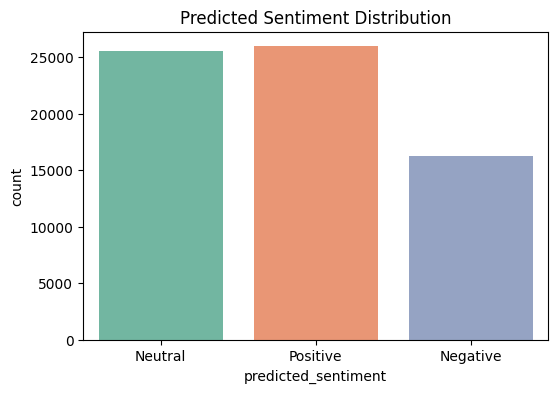

In [10]:
# Sentiment Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='predicted_sentiment', data=data, palette='Set2')
plt.title("Predicted Sentiment Distribution")
plt.show()


In [ ]:
#Word Cloud

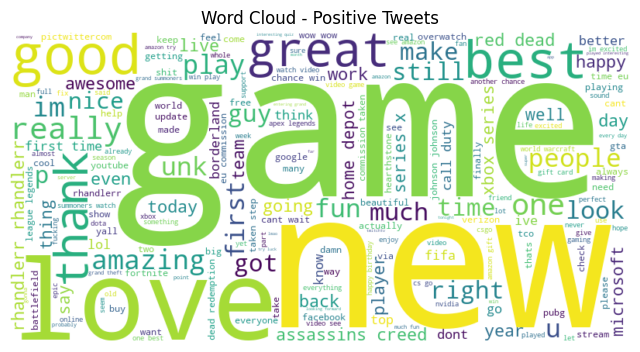

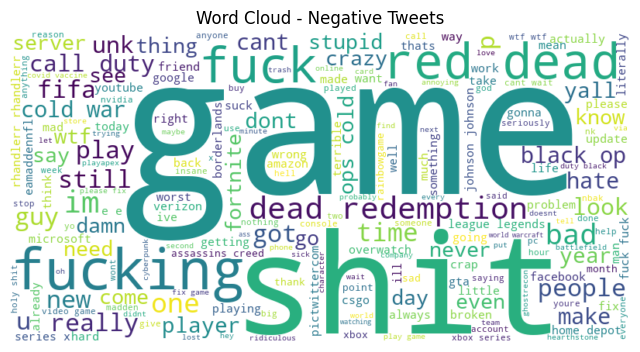

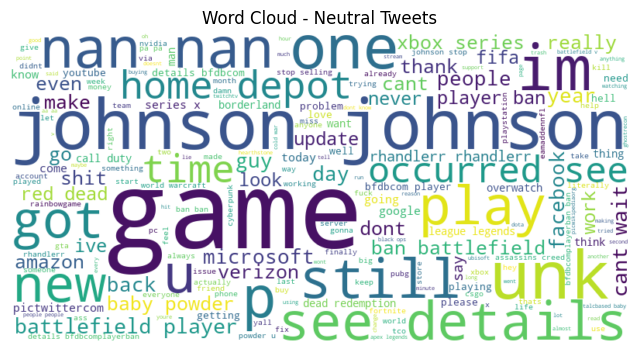

In [11]:
for sentiment in ['Positive', 'Negative', 'Neutral']:
    text = ' '.join(data[data['predicted_sentiment'] == sentiment]['clean_text'])
    if text.strip():
        wc = WordCloud(width=800, height=400, background_color='white').generate(text)
        plt.figure(figsize=(8,5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Word Cloud - {sentiment} Tweets")
        plt.show()


In [12]:
output_path = r"C:\Users\shivani\OneDrive\Desktop\23p65a6717\sentiment_results.csv"
data.to_csv(output_path, index=False, encoding='utf-8')
print(f"✅ Results saved to: {output_path}")


✅ Results saved to: C:\Users\shivani\OneDrive\Desktop\23p65a6717\sentiment_results.csv
